In [8]:
from src.dataloading.epiconfig import EpiConfig
from src.dataloading.epidataorchestration import EpiDataOrchestrator
from src.dataloading.dataloaders import BaseLineDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel, ConstantModel, ClimaScaleModel, LSTMModel, DecoupledGCNModel

epiconfig= EpiConfig(
        disease             = 'covid_daily',
        country             = 'germany',
        level               = 'nuts3',

        horizon_leadtime    = 7,
        sequence_length     = 7,

        temporal_frequency  = 'd',
        time_index_d        = True,
        time_index_w        = False,

        min_date            = '2021-09-01',
        max_date            =  '2023-01-01', 

        split_trainval      = '2022-06-01',
        split_valtest       = '2022-09-01',

        feature_popsize     = True,      
        feature_popdens     = True,
        # feature_gisd        = True,
        # feature_popage      = True,
        # feature_kreise_classes= True,
        
        log_transform       = ['incidence']     
        )    

data_orch= EpiDataOrchestrator(epiconfig).build()

correct peak time


In [9]:
from src.dataloading.epidataorchestration.previewer import EpiDataPreviewer

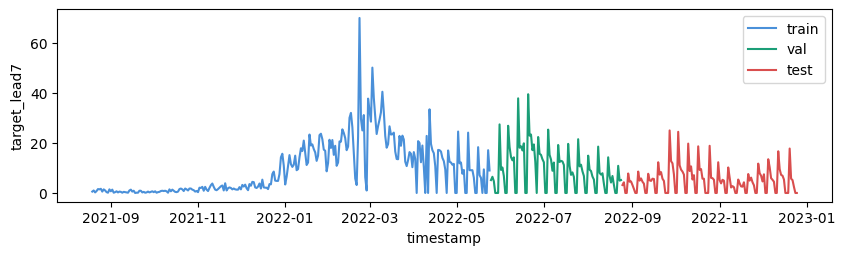

In [10]:
EpiDataPreviewer(data_orch).splits()

In [11]:
from src.dataloading.dataloaders import BaseLineDataLoaderManager, DeepDataLoaderManager,GraphDataLoaderManager

n_epochs        = 250
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.2, 'patience': 5},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

baselinedataloader  = BaseLineDataLoaderManager(data_orch)
deepdataloader      = DeepDataLoaderManager(data_orch).build()
graphloader1        = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph1').build()
graphloader2        = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph2').build()
graphloader3        = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph3').build()
graphloader4        = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph4').build()
graphloader5        = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph5').build()
graphloader6        = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph6').build()
graphloader10       = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph10').build()
graphloader13       = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph13').build()
graphloader16       = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph16').build()


==                     gcn2                     ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 5, 7), y=(400, 1), edge_index=(2, 2088), edge_weight=(2088,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.6763   |   0.4912   |    v     |           |
|  002  |   0.5108   |   0.4387   |    v     |           |
|  003  |   0.4532   |   0.3953   |    v     |           |
|  004  |   0.4181   |   0.3721   |    v     |           |
|  005  |   0.3924   |   0.3497   |    v     |           |
|  006  |   0.3744   |   0.3367   |    v     |           |
|  007  |   0.3594   |   0.3242   |    v     |           |
|  008  |   0.3487   |   0.3128   |    v     |           |
|  009  |   0.3385   |   0.2993   |    v     |           |
|  010  |   0.3294   |   0.2883   |    v     |           |
|  011  |   0.3223   |   0.2811   |    v     |           |
|  012  |   0.3150   |   0.2741   |    

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.2065
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 123/123 [00:00<00:00, 665.23it/s]


Test loss: 0.1990
forecasted ✓


<Fig(n_axes = 1, legend, ticks, labels)>

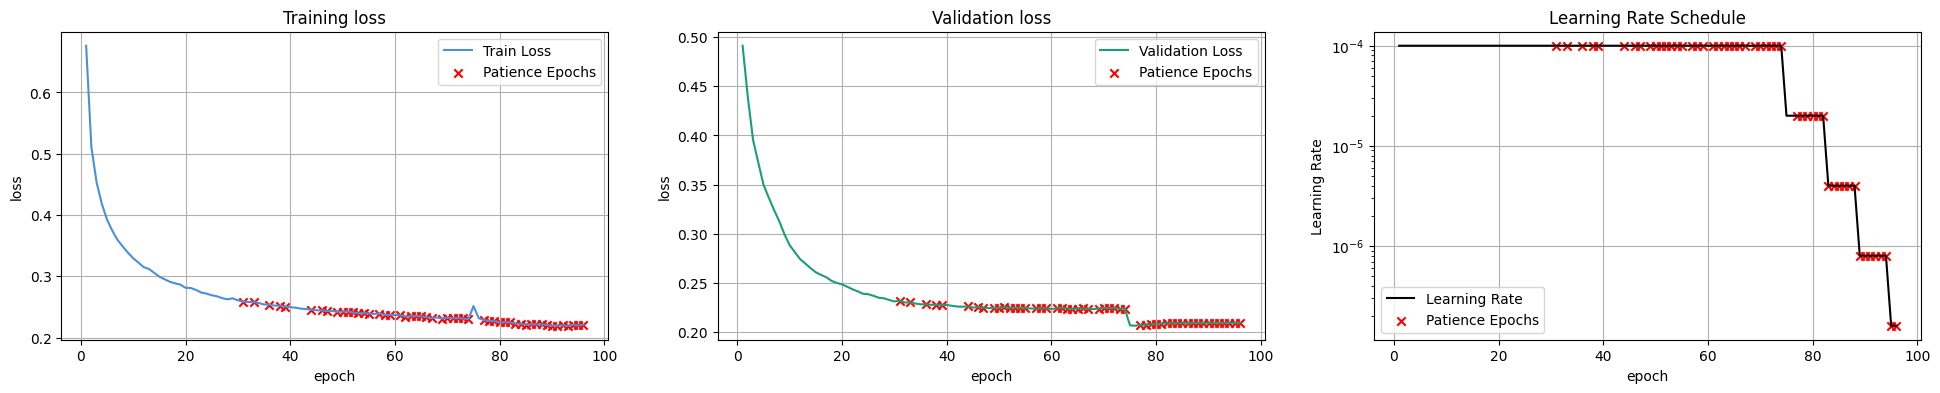

In [12]:

from src.models import GCN2Model
gcn2 = GCN2Model(graphloader2, name = 'gcn2', verbose = 2)
gcn2.set_model_hparams(dropout = 0.3, self_loops=False)
gcn2.set_global_hparams(**global_hparams)
gcn2.train()
gcn2.forecast('test')
gcn2.show_forecasts(26)


==                    gcn16                     ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 5, 7), y=(400, 1), edge_index=(2, 1390), edge_weight=(1390,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.6260   |   0.6745   |    v     |           |
|  002  |   0.5013   |   0.5009   |    v     |           |
|  003  |   0.4192   |   0.4070   |    v     |           |
|  004  |   0.3909   |   0.3475   |    v     |           |
|  005  |   0.3704   |   0.3177   |    v     |           |
|  006  |   0.3552   |   0.2970   |    v     |           |
|  007  |   0.3420   |   0.2826   |    v     |           |
|  008  |   0.3303   |   0.2710   |    v     |           |
|  009  |   0.3231   |   0.2634   |    v     |           |
|  010  |   0.3185   |   0.2594   |    v     |           |
|  011  |   0.3127   |   0.2574   |    v     |           |
|  012  |   0.3072   |   0.2574   |    

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.1962
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 123/123 [00:00<00:00, 431.96it/s]


Test loss: 0.2057
forecasted ✓


DecoupledGCNModel(name='gcn16')

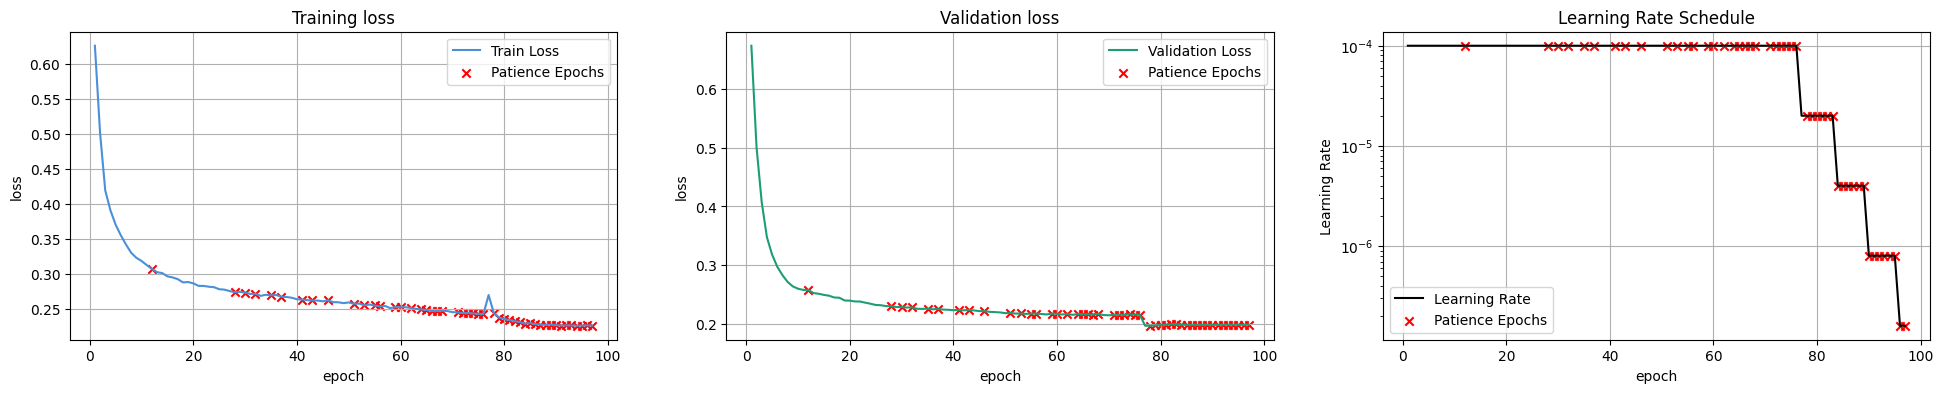

In [24]:

from src.models import DecoupledGCNModel
gcn16 = DecoupledGCNModel(graphloader16, name = 'gcn16', verbose = 2)
gcn16.set_model_hparams(dropout = 0.3)
gcn16.set_global_hparams(**global_hparams)
gcn16.train()
gcn16.forecast('test')


In [14]:
from src.models import ClimaScaleModel, PersistenceModel, ClimateologyModel 
from src.evaluation import Evaluator

persistence = PersistenceModel(baselinedataloader)
persistence.forecast()

climateology = ClimateologyModel(baselinedataloader)
climateology.forecast()

climascale = ClimaScaleModel(baselinedataloader)
climascale.forecast()

baseline_models = [persistence, climateology, climascale]

In [25]:


models = baseline_models + [gcn2, gcn16]

model_evaluation = Evaluator(models).add_evaluation()

computing metrics nodewise:   0%|                                                                                                                                                    | 0/2000 [00:00<?, ?it/s]

computing metrics nodewise: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:02<00:00, 753.93it/s]


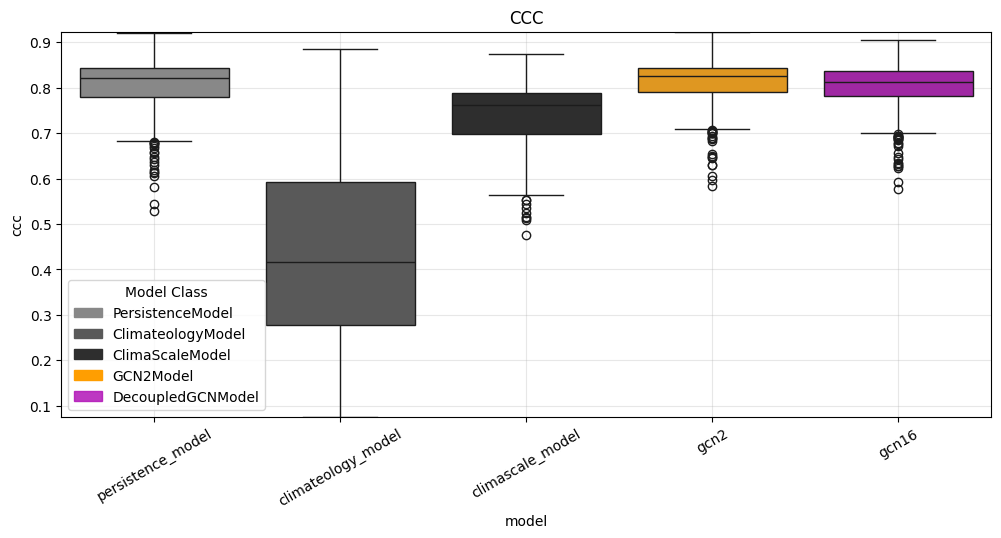

In [26]:
model_evaluation.plotter.plot_metric(0,'test','ccc','box').show()

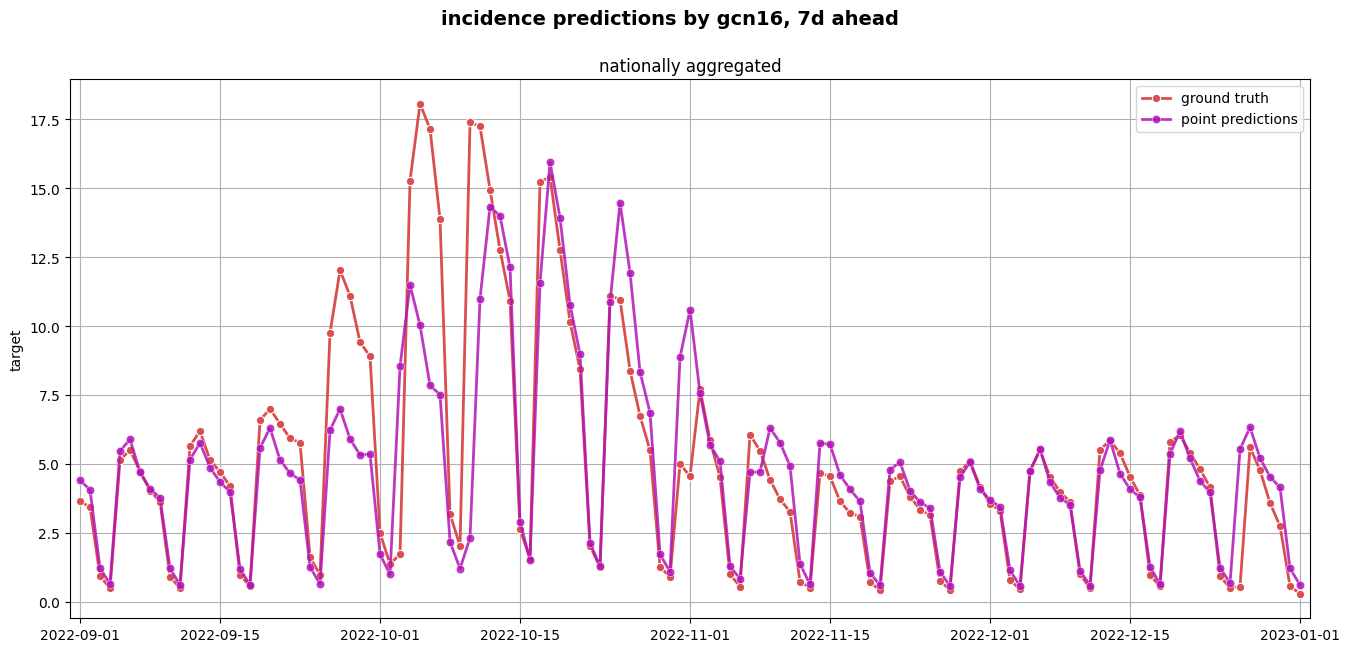

In [27]:
gcn16.show_forecasts('national').show()